# Pandas 
## (Data Analysis with pandas)

### Series 

In [5]:
# 1-D data

import pandas as pd
import numpy as np

# Creating an empty series, will result in DeprecationWarning
#series = pd.Series()

# Passing dtype as a parameter to Series for an empty series to avoid DeprecationWarning
# Creating an empty series
series = pd.Series(dtype='float64')
# Newline to separate series print statements
print('{}\n'.format(series))

series = pd.Series(5)
print('{}\n'.format(series))

series = pd.Series([1, 2, 3])
print('{}\n'.format(series))

series = pd.Series([1, 2.2]) # upcasting
print('{}\n'.format(series))

arr = np.array([1, 2])
series = pd.Series(arr, dtype=np.float32)
print('{}\n'.format(series))

series = pd.Series([[1, 2], [3, 4]])
print('{}\n'.format(series))


Series([], dtype: float64)

0    5
dtype: int64

0    1
1    2
2    3
dtype: int64

0    1.0
1    2.2
dtype: float64

0    1.0
1    2.0
dtype: float32

0    [1, 2]
1    [3, 4]
dtype: object



In [2]:
# Index 


series = pd.Series([1, 2, 3], index=['a', 'b', 'c'])
print('{}\n'.format(series))

series = pd.Series([1, 2, 3], index=['a', 8, 0.3])
print('{}\n'.format(series))


a    1
b    2
c    3
dtype: int64

a      1
8      2
0.3    3
dtype: int64



In [3]:
# Dictionary input 

series = pd.Series({'a':1, 'b':2, 'c':3})
print('{}\n'.format(series))

series = pd.Series({'b':2, 'a':1, 'c':3})
print('{}\n'.format(series))

a    1
b    2
c    3
dtype: int64

b    2
a    1
c    3
dtype: int64



### DataFrame 

In [ ]:
# 2-D data 

df = pd.DataFrame()
# Newline added to separate DataFrames
print('{}\n'.format(df))

df = pd.DataFrame([5, 6])
print('{}\n'.format(df))

df = pd.DataFrame([[5,6]])
print('{}\n'.format(df))

df = pd.DataFrame([[5, 6], [1, 3]],
                  index=['r1', 'r2'],
                  columns=['c1', 'c2'])
print('{}\n'.format(df))

df = pd.DataFrame({'c1': [1, 2], 'c2': [3, 4]},
                  index=['r1', 'r2']) 
print('{}\n'.format(df))

Empty DataFrame
Columns: []
Index: []

   0
0  5
1  6

   0  1
0  5  6

    c1  c2
r1   5   6
r2   1   3

    c1  c2
r1   1   3
r2   2   4



In [5]:
# Upcasting 

upcast = pd.DataFrame([[5, 6], [1.2, 3]])
print('{}\n'.format(upcast))
# Datatypes of each column
print(upcast.dtypes)

     0  1
0  5.0  6
1  1.2  3

0    float64
1      int64
dtype: object


In [ ]:
# Appending rows 

df = pd.DataFrame([[5, 6], [1.2, 3]])
ser = pd.Series([0, 0], name='r3')

df_app = df.append(ser)
print('{}\n'.format(df_app))

df_app = df.append(ser, ignore_index=True)
print('{}\n'.format(df_app))

df2 = pd.DataFrame([[0,0],[9,9]])
df_app = df.append(df2)
print('{}\n'.format(df_app))  


#  op 

# Output
# 1.54s
#       0  1
# 0   5.0  6
# 1   1.2  3
# r3  0.0  0

#      0  1
# 0  5.0  6
# 1  1.2  3
# 2  0.0  0

#      0  1
# 0  5.0  6
# 1  1.2  3
# 0  0.0  0
# 1  9.0  9


In [12]:
# Dropping data 


df = pd.DataFrame({'c1': [1, 2], 'c2': [3, 4],
                   'c3': [5, 6]},
                  index=['r1', 'r2'])
# Drop row r1
df_drop = df.drop(labels='r1')
print('{}\n'.format(df_drop))

# Drop columns c1, c3
df_drop = df.drop(labels=['c1', 'c3'], axis=1)
print('{}\n'.format(df_drop))

df_drop = df.drop(index='r2')
print('{}\n'.format(df_drop))

df_drop = df.drop(columns='c2')
print('{}\n'.format(df_drop))

df.drop(index='r2', columns='c2')
print('{}\n'.format(df_drop))


    c1  c2  c3
r2   2   4   6

    c2
r1   3
r2   4

    c1  c2  c3
r1   1   3   5

    c1  c3
r1   1   5
r2   2   6

    c1  c3
r1   1   5
r2   2   6



### Combining 

In [13]:
# pd.concat 

df1 = pd.DataFrame({'c1':[1,2], 'c2':[3,4]},
                   index=['r1','r2'])
df2 = pd.DataFrame({'c1':[5,6], 'c2':[7,8]},
                   index=['r1','r2'])
df3 = pd.DataFrame({'c1':[5,6], 'c2':[7,8]})

concat = pd.concat([df1, df2], axis=1)
# Newline to separate print statements
print('{}\n'.format(concat))

concat = pd.concat([df2, df1, df3])
print('{}\n'.format(concat))

concat = pd.concat([df1, df3], axis=1)
print('{}\n'.format(concat))

    c1  c2  c1  c2
r1   1   3   5   7
r2   2   4   6   8

    c1  c2
r1   5   7
r2   6   8
r1   1   3
r2   2   4
0    5   7
1    6   8

     c1   c2   c1   c2
r1  1.0  3.0  NaN  NaN
r2  2.0  4.0  NaN  NaN
0   NaN  NaN  5.0  7.0
1   NaN  NaN  6.0  8.0



In [14]:
# Merging 

mlb_df1 = pd.DataFrame({'name': ['john doe', 'al smith', 'sam black', 'john doe'],
                        'pos': ['1B', 'C', 'P', '2B'],
                        'year': [2000, 2004, 2008, 2003]})
mlb_df2 = pd.DataFrame({'name': ['john doe', 'al smith', 'jack lee'],
                        'year': [2000, 2004, 2012],
                        'rbi': [80, 100, 12]})
                        
print('{}\n'.format(mlb_df1))
print('{}\n'.format(mlb_df1))

mlb_merged = pd.merge(mlb_df1, mlb_df2)
print('{}\n'.format(mlb_merged))

        name pos  year
0   john doe  1B  2000
1   al smith   C  2004
2  sam black   P  2008
3   john doe  2B  2003

        name pos  year
0   john doe  1B  2000
1   al smith   C  2004
2  sam black   P  2008
3   john doe  2B  2003

       name pos  year  rbi
0  john doe  1B  2000   80
1  al smith   C  2004  100



### Indexing 

In [16]:
# Direct indexing 


df = pd.DataFrame({'c1': [1, 2], 'c2': [3, 4],
                   'c3': [5, 6]}, index=['r1', 'r2'])
col1 = df['c1']
# Newline for separating print statements
print('{}\n'.format(col1))

col1_df = df[['c1']]
print('{}\n'.format(col1_df))

col23 = df[['c2', 'c3']]
print('{}\n'.format(col23))

r1    1
r2    2
Name: c1, dtype: int64

    c1
r1   1
r2   2

    c2  c3
r1   3   5
r2   4   6



In [18]:
# directly index into a DataFrame's rows 


df = pd.DataFrame({'c1': [1, 2, 3], 'c2': [4, 5, 6],
                   'c3': [7, 8, 9]}, index=['r1', 'r2', 'r3'])

print('{}\n'.format(df))

first_two_rows = df[0:2]
print('{}\n'.format(first_two_rows))

last_two_rows = df['r2':'r3']
print('{}\n'.format(last_two_rows))

# There will be a KeyError when we uncomment the line 13 and run again
#df['r1']

    c1  c2  c3
r1   1   4   7
r2   2   5   8
r3   3   6   9

    c1  c2  c3
r1   1   4   7
r2   2   5   8

    c1  c2  c3
r2   2   5   8
r3   3   6   9



In [19]:
# Other indexing 

df = pd.DataFrame({'c1': [1, 2, 3], 'c2': [4, 5, 6],
                   'c3': [7, 8, 9]}, index=['r1', 'r2', 'r3'])
                   
print('{}\n'.format(df))

print('{}\n'.format(df.iloc[1]))

print('{}\n'.format(df.iloc[[0, 2]]))

bool_list = [False, True, True]
print('{}\n'.format(df.iloc[bool_list]))

    c1  c2  c3
r1   1   4   7
r2   2   5   8
r3   3   6   9

c1    2
c2    5
c3    8
Name: r2, dtype: int64

    c1  c2  c3
r1   1   4   7
r3   3   6   9

    c1  c2  c3
r2   2   5   8
r3   3   6   9



In [20]:
# usages of loc 

df = pd.DataFrame({'c1': [1, 2, 3], 'c2': [4, 5, 6],
                   'c3': [7, 8, 9]}, index=['r1', 'r2', 'r3'])
                   
print('{}\n'.format(df))

print('{}\n'.format(df.loc['r2']))

bool_list = [False, True, True]
print('{}\n'.format(df.loc[bool_list]))

single_val = df.loc['r1', 'c2']
print('Single val: {}\n'.format(single_val))

print('{}\n'.format(df.loc[['r1', 'r3'], 'c2']))

df.loc[['r1', 'r3'], 'c2'] = 0
print('{}\n'.format(df))

    c1  c2  c3
r1   1   4   7
r2   2   5   8
r3   3   6   9

c1    2
c2    5
c3    8
Name: r2, dtype: int64

    c1  c2  c3
r2   2   5   8
r3   3   6   9

Single val: 4

r1    4
r3    6
Name: c2, dtype: int64

    c1  c2  c3
r1   1   0   7
r2   2   5   8
r3   3   0   9



### File I/O

In [ ]:
#  Reading data  csv

# data.csv contains baseball data
df = pd.read_csv('data.csv')
# Newline to separate print statements
print('{}\n'.format(df))

df = pd.read_csv('data.csv', index_col=0)
print('{}\n'.format(df))

df = pd.read_csv('data.csv', index_col=1)
print('{}\n'.format(df))

NameError: name 'pd' is not defined

In [ ]:
#  pd.read_excel.


# data.csv contains baseball data
df = pd.read_excel('data.xlsx')
# Newline to separate print statements
print('{}\n'.format(df))

print('Sheet 1 (0-indexed) DataFrame:')
df = pd.read_excel('data.xlsx', sheet_name=1)
print('{}\n'.format(df))

print('MIL DataFrame:')
df = pd.read_excel('data.xlsx', sheet_name='MIL')
print('{}\n'.format(df))

# Sheets 0 and 1
df_dict = pd.read_excel('data.xlsx', sheet_name=[0, 1])
print('{}\n'.format(df_dict[1]))

# All Sheets
df_dict = pd.read_excel('data.xlsx', sheet_name=None)
print(df_dict.keys())

In [ ]:
# JSON 

# data is the JSON data (as a Python dict)
print('{}\n'.format(data))

df1 = pd.read_json('data.json')
print('{}\n'.format(df1))

df2 = pd.read_json('data.json', orient='index')
print('{}\n'.format(df2))

In [ ]:
# Writing to files  csv

# Predefined mlb_df
print('{}\n'.format(mlb_df))

# Index is kept when writing
mlb_df.to_csv('data.csv')
df = pd.read_csv('data.csv')
print('{}\n'.format(df))

# Index is not kept when writing
mlb_df.to_csv('data.csv', index=False)
df = pd.read_csv('data.csv')
print('{}\n'.format(df))

In [ ]:
# Excel

# Predefined DataFrames
print('{}\n'.format(mlb_df1))
print('{}\n'.format(mlb_df2))

with pd.ExcelWriter('data.xlsx') as writer:
  mlb_df1.to_excel(writer, index=False, sheet_name='NYY')
  mlb_df2.to_excel(writer, index=False, sheet_name='BOS')
  
df_dict = pd.read_excel('data.xlsx', sheet_name=None)
print(df_dict.keys())
print('{}\n'.format(df_dict['BOS']))

### Grouping

In [1]:
# Grouping by column
# Predefined df of MLB stats
print('{}\n'.format(df))

groups = df.groupby('yearID')
for name, group in groups:
  print('Year: {}'.format(name))
  print('{}\n'.format(group))
  
print('{}\n'.format(groups.get_group(2016)))
print('{}\n'.format(groups.sum()))
print('{}\n'.format(groups.mean()))

NameError: name 'df' is not defined

In [ ]:
# Multiple columns 

# player_df is predefined
groups = player_df.groupby(['yearID', 'teamID'])

for name, group in groups:
  print('Year, Team: {}'.format(name))
  print('{}\n'.format(group))

print(groups.sum())

### Features 

In [ ]:
# Quantitative features  

df = pd.DataFrame({
  'T1': [10, 15, 8],
  'T2': [25, 27, 25],
  'T3': [16, 15, 10]})
  
print('{}\n'.format(df))

print('{}\n'.format(df.sum()))

print('{}\n'.format(df.sum(axis=1)))

print('{}\n'.format(df.mean()))

print('{}\n'.format(df.mean(axis=1)))

In [ ]:
# Weighted features 

df = pd.DataFrame({
  'T1': [0.1, 150.],
  'T2': [0.25, 240.],
  'T3': [0.16, 100.]})
  
print('{}\n'.format(df))

print('{}\n'.format(df.multiply(2)))

df_ms = df.multiply([1000, 1], axis=0)
print('{}\n'.format(df_ms))

df_w = df_ms.multiply([1,0.5,1])
print('{}\n'.format(df_w))
print('{}\n'.format(df_w.sum(axis=1)))

### Filtering 

In [2]:
# Filter conditions 

df = pd.DataFrame({
  'playerID': ['bettsmo01', 'canoro01', 'cruzne02', 'ortizda01', 'cruzne02'],
  'yearID': [2016, 2016, 2016, 2016, 2017],
  'teamID': ['BOS', 'SEA', 'SEA', 'BOS', 'SEA'],
  'HR': [31, 39, 43, 38, 39]})
  
print('{}\n'.format(df))

cruzne02 = df['playerID'] == 'cruzne02'
print('{}\n'.format(cruzne02))

hr40 = df['HR'] > 40
print('{}\n'.format(hr40))

notbos = df['teamID'] != 'BOS'
print('{}\n'.format(notbos))

NameError: name 'pd' is not defined

In [ ]:
# Filters from functions 

df = pd.DataFrame({
  'playerID': ['bettsmo01', 'canoro01', 'cruzne02', 'ortizda01', 'cruzne02'],
  'yearID': [2016, 2016, 2016, 2016, 2017],
  'teamID': ['BOS', 'SEA', 'SEA', 'BOS', 'SEA'],
  'HR': [31, 39, 43, 38, 39]})
  
print('{}\n'.format(df))

str_f1 = df['playerID'].str.startswith('c')
print('{}\n'.format(str_f1))

str_f2 = df['teamID'].str.endswith('S')
print('{}\n'.format(str_f2))

str_f3 = ~df['playerID'].str.contains('o')
print('{}\n'.format(str_f3))

In [7]:
# Feature filtering 

df = pd.DataFrame({
  'playerID': ['bettsmo01', 'canoro01', 'cruzne02', 'ortizda01', 'bettsmo01'],
  'yearID': [2016, 2016, 2016, 2016, 2015],
  'teamID': ['BOS', 'SEA', 'SEA', 'BOS', 'BOS'],
  'HR': [31, 39, 43, 38, 18]})
  
print('{}\n'.format(df))

hr40_df = df[df['HR'] > 40]
print('{}\n'.format(hr40_df))

not_hr30_df = df[~(df['HR'] > 30)]
print('{}\n'.format(not_hr30_df))

str_df = df[df['teamID'].str.startswith('B')]
print('{}\n'.format(str_df))

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18

   playerID  yearID teamID  HR
2  cruzne02    2016    SEA  43

    playerID  yearID teamID  HR
4  bettsmo01    2015    BOS  18

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18



###  Sorting 

In [8]:
# Sorting by feature

# df is predefined
print('{}\n'.format(df))

sort1 = df.sort_values('yearID')
print('{}\n'.format(sort1))

sort2 = df.sort_values('playerID', ascending=False)
print('{}\n'.format(sort2))


    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18

    playerID  yearID teamID  HR
4  bettsmo01    2015    BOS  18
0  bettsmo01    2016    BOS  31
2   cruzne02    2016    SEA  43
1   canoro01    2016    SEA  39
3  ortizda01    2016    BOS  38

    playerID  yearID teamID  HR
3  ortizda01    2016    BOS  38
2   cruzne02    2016    SEA  43
1   canoro01    2016    SEA  39
0  bettsmo01    2016    BOS  31
4  bettsmo01    2015    BOS  18



### Metrics 

In [ ]:
# Numeric metrics 

# Metric	Description
# count	The number of rows in the DataFrame
# mean	The mean value for a feature
# std	 The standard deviation for a feature
# min	 The minimum value in a feature
# 25%	 The 25th percentile of a feature
# 50%	 The 50th percentile of a feature. Note that this is identical to the median
# 75%	 The 75th percentile of a feature
# max	 The maximum value in a feature

In [9]:
# df is predefined
print('{}\n'.format(df))

metrics1 = df.describe()
print('{}\n'.format(metrics1))

hr_rbi = df[['HR','RBI']]
metrics2 = hr_rbi.describe()
print('{}\n'.format(metrics2))

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18

            yearID         HR
count     5.000000   5.000000
mean   2015.800000  33.800000
std       0.447214   9.833616
min    2015.000000  18.000000
25%    2016.000000  31.000000
50%    2016.000000  38.000000
75%    2016.000000  39.000000
max    2016.000000  43.000000



KeyError: "['RBI'] not in index"

In [10]:
# Categorical features 


p_ids = df['playerID']
print('{}\n'.format(p_ids.value_counts()))

print('{}\n'.format(p_ids.value_counts(normalize=True)))

print('{}\n'.format(p_ids.value_counts(ascending=True)))

playerID
bettsmo01    2
canoro01     1
cruzne02     1
ortizda01    1
Name: count, dtype: int64

playerID
bettsmo01    0.4
canoro01     0.2
cruzne02     0.2
ortizda01    0.2
Name: proportion, dtype: float64

playerID
canoro01     1
cruzne02     1
ortizda01    1
bettsmo01    2
Name: count, dtype: int64



###  Plotting  

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18



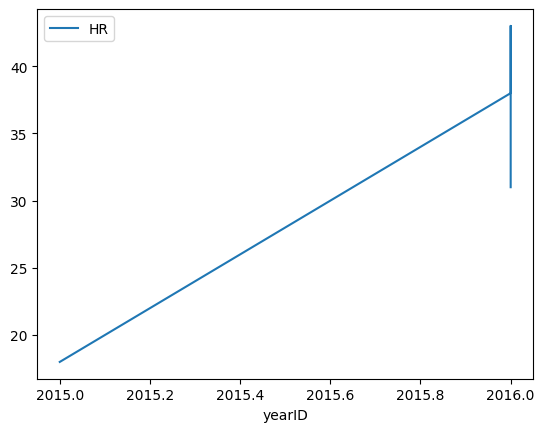

In [12]:
# Basics

# predefined df
import matplotlib.pyplot as plt
print('{}\n'.format(df))

df.plot(kind='line',x='yearID',y='HR')
plt.show()

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18



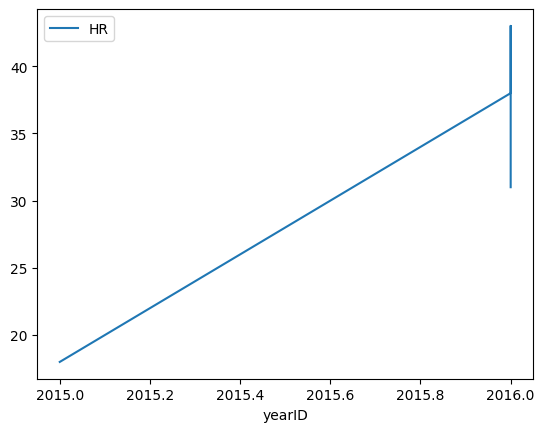

FileNotFoundError: [Errno 2] No such file or directory: 'output/legend.png'

<Figure size 640x480 with 0 Axes>

In [13]:
#  use plt.savefig 

# predefined df
print('{}\n'.format(df))

df.plot(kind='line',x='yearID',y='HR')
plt.show()
plt.savefig('output/legend.png')  # save to PNG file

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18



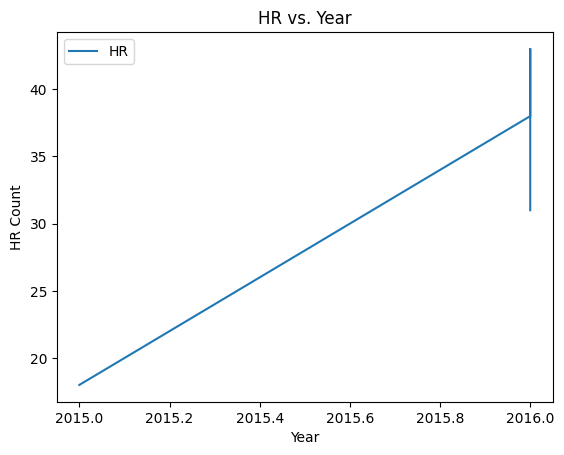

In [14]:
# no title or y-axis label 


# predefined df
print('{}\n'.format(df))

df.plot(kind='line',x='yearID',y='HR')
plt.title('HR vs. Year')
plt.xlabel('Year')
plt.ylabel('HR Count')
plt.show()

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18



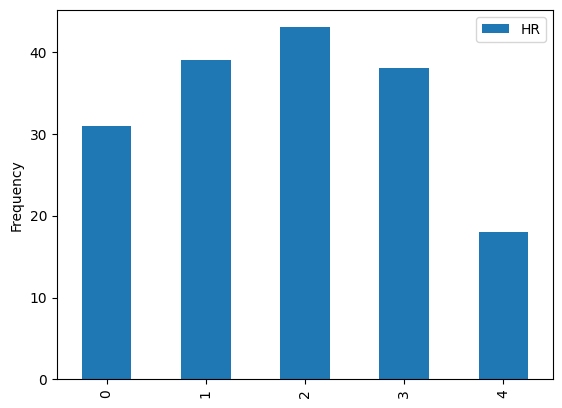

In [15]:
# Other plots 

# predefined df
print('{}\n'.format(df))

df.plot(kind='bar',y='HR')
plt.ylabel('Frequency')
plt.show()

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18



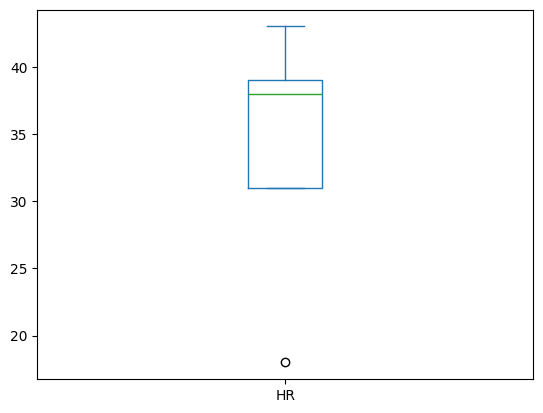

In [16]:
# other 

# predefined df
print('{}\n'.format(df))

df.plot(kind='box',y='HR')
plt.show()

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18



KeyError: 'H'

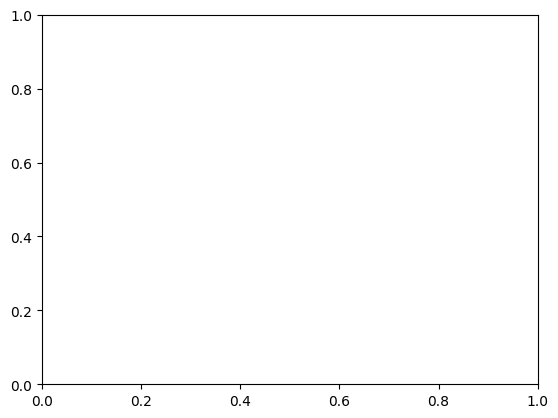

In [17]:
# Multiple features 


# predefined df
print('{}\n'.format(df))

# gca stands for 'get current axis'
ax = plt.gca()

df.plot(kind='line',x='yearID',y='H',ax=ax)
df.plot(kind='line',x='yearID',y='BB', color='red', ax=ax)
plt.show()

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18



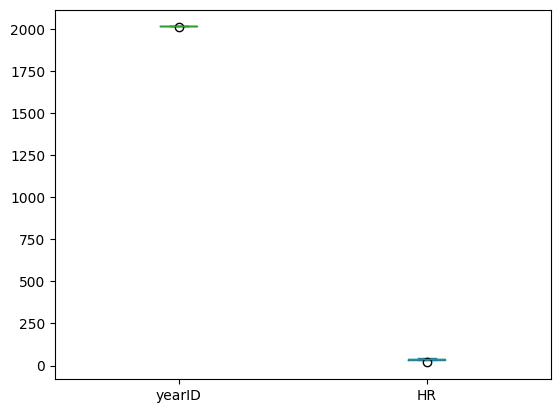

In [18]:
# other 

# predefined df
print('{}\n'.format(df))

df.plot(kind='box')
plt.show()

### To NumPy 

In [20]:
# Machine learning 
# Indicator features 

indicator_df = pd.DataFrame({
    'Feature1': [1, 0, 1, 0],
    'Feature2': [0, 1, 0, 1]
})

# predefined non-indicator DataFrame
print('{}\n'.format(df))

# predefined indicator Dataframe
print('{}\n'.format(indicator_df))


    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18

   Feature1  Feature2
0         1         0
1         0         1
2         1         0
3         0         1



In [21]:
# Converting to indicators 

# predefined df
print('{}\n'.format(df))

converted = pd.get_dummies(df)
print('{}\n'.format(converted.columns))

print('{}\n'.format(converted[['teamID_BOS',
                               'teamID_PIT']]))
print('{}\n'.format(converted[['lgID_AL',
                               'lgID_NL']]))

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18

Index(['yearID', 'HR', 'playerID_bettsmo01', 'playerID_canoro01',
       'playerID_cruzne02', 'playerID_ortizda01', 'teamID_BOS', 'teamID_SEA'],
      dtype='object')



KeyError: "['teamID_PIT'] not in index"

In [22]:
# Converting to NumPy 

# predefined indicator df
print('{}\n'.format(df))

n_matrix = df.values
print(repr(n_matrix)) 

    playerID  yearID teamID  HR
0  bettsmo01    2016    BOS  31
1   canoro01    2016    SEA  39
2   cruzne02    2016    SEA  43
3  ortizda01    2016    BOS  38
4  bettsmo01    2015    BOS  18

array([['bettsmo01', 2016, 'BOS', 31],
       ['canoro01', 2016, 'SEA', 39],
       ['cruzne02', 2016, 'SEA', 43],
       ['ortizda01', 2016, 'BOS', 38],
       ['bettsmo01', 2015, 'BOS', 18]], dtype=object)
